In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
# load temperature data
temp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\air.mon.mean.nc")
temp = temp.sel(time = slice('1980', '2020')) 
temp.load()

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
Data variables:
    air      (time, lat, lon) float32 -26.17 -26.17 -26.17 ... -22.16 -22.16
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [3]:
ds_climo = temp.groupby('time.month').mean()
ds_anoms = temp.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    air      (time, lat, lon) float32 2.491 2.491 2.491 ... 0.9349 0.9349 0.9349

In [16]:
from sklearn.cluster import KMeans

In [17]:
#select domain
latS = 10
latN = 30
lonL = 100
lonR = 140
ds_anoms_TP = ds_anoms.sel(lat = slice(latN, latS), lon = slice(lonL, lonR))

nt = len(ds_anoms_TP['time'])
ny = len(ds_anoms_TP['lat'])
nx = len(ds_anoms_TP['lon'])
print(nt, ny, nx)
data = ds_anoms_TP['air'].values
ds_anoms_2d = np.reshape(data, [nt, ny*nx],order='F')
mk2 = KMeans(n_clusters = 4).fit(ds_anoms_2d)

492 9 17


c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [18]:
def get_cluster_fraction(m, label):        
        return (m.labels_==label).sum()/(m.labels_.size*1.0)

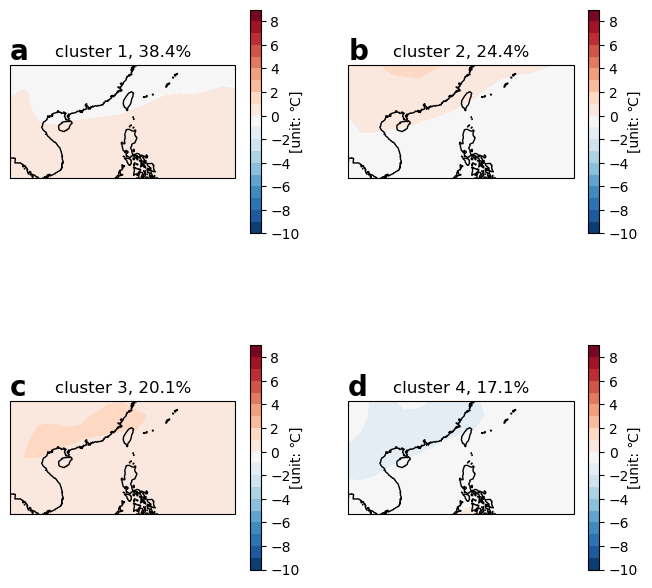

In [20]:
x,y = np.meshgrid(ds_anoms_TP.lon, ds_anoms_TP.lat)
proj = ccrs.PlateCarree(central_longitude = 180)
fig, axes = plt.subplots(2,2, figsize = (8,8), subplot_kw = dict(projection = proj))
regimes = ['cluster 1', 'cluster 2', 'cluster 3', 'cluster 4']
tags = list('abcd')
for i in range(mk2.n_clusters):
    onecen = mk2.cluster_centers_[i,:].reshape(ny,nx, order = 'F')
    cs = axes.flat[i].contourf(x, y, onecen,
                               levels = np.arange(-10, 10, 1), 
                               transform = ccrs.PlateCarree(),
                               cmap = 'RdBu_r')
    
    cb=fig.colorbar(cs, ax = axes.flat[i], shrink = 0.8, aspect = 20) 
    cb.set_label('[unit: ℃]',labelpad = -7)    
    axes.flat[i].coastlines()
    axes.flat[i].set_global()
    axes.flat[i].set_extent([lonL, lonR, latS, latN],crs=ccrs.PlateCarree())

    title = '{}, {:4.1f}%'.format(regimes[i], get_cluster_fraction(mk2, i)*100)
    axes.flat[i].set_title(title)
    plt.text(0, 1, tags[i], 
             transform=axes.flat[i].transAxes, 
             va='bottom', 
             fontsize=plt.rcParams['font.size']*2, 
             fontweight='bold')